# 10 - Confidence and Prediction Intervals

Un modelo de regresion nos da **un numero** como prediccion. Pero en la realidad, hay **incertidumbre**.

- **Confidence Interval**: incertidumbre sobre los **coeficientes** o la **media** de la prediccion
- **Prediction Interval**: incertidumbre sobre una **prediccion individual**

El prediction interval siempre es **mas ancho** que el confidence interval.

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("../data/housing.csv")
df.head()

,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality
0,1,51,5,152700,2,1,2,4.7,0,5
1,2,52,44,132300,2,1,10,4.3,1,3
2,3,56,36,183200,2,1,1,6.6,1,6
3,4,57,6,170100,3,2,8,14.0,1,5
4,5,58,21,109500,2,1,1,18.0,1,5


## 1. Confidence Intervals para coeficientes (con formulas)

`statsmodels` calcula intervalos de confianza para cada coeficiente automaticamente.

In [6]:
predictors = ["square_meters", "bathrooms", "build_quality", "distance_to_center_km"]
X = df[predictors]
y = df["price"]
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

# Intervalos de confianza al 95%
ci = model.conf_int(alpha=0.05)
ci.columns = ["2.5%", "97.5%"]
ci["Coeficiente"] = model.params
ci["Ancho del intervalo"] = ci["97.5%"] - ci["2.5%"]
print("Intervalos de confianza (95%) para los coeficientes:")
print(ci[["Coeficiente", "2.5%", "97.5%", "Ancho del intervalo"]].round(2))
print("\nSi el intervalo incluye 0, el coeficiente NO es significativo")

Intervalos de confianza (95%) para los coeficientes:
                       Coeficiente     2.5%     97.5%  Ancho del intervalo
const                     35062.53 -2279.98  72405.05             74685.03
square_meters              1210.03   887.68   1532.38               644.70
bathrooms                 23519.22  9495.77  37542.66             28046.88
build_quality              6549.56  1294.78  11804.34             10509.57
distance_to_center_km     -2587.01 -3680.90  -1493.13              2187.77

Si el intervalo incluye 0, el coeficiente NO es significativo


## 2. Bootstrap: confidence intervals para coeficientes

El bootstrap es otra forma de calcular intervalos de confianza, **sin asumir distribucion normal**.

Algoritmo:
1. Tomar una muestra con reemplazo (mismo tamano que los datos)
2. Ajustar regresion y guardar coeficientes
3. Repetir 1000 veces
4. Tomar percentiles 2.5% y 97.5%

In [8]:
rng = np.random.default_rng(42)
n_bootstrap = 1000
n = len(df)

X_np = df[predictors].to_numpy()
y_np = df["price"].to_numpy()

# Guardar coeficientes de cada bootstrap
boot_coefs = np.zeros((n_bootstrap, len(predictors)))

for i in range(n_bootstrap):
    idx = rng.choice(n, size=n, replace=True)
    X_boot = X_np[idx]
    y_boot = y_np[idx]
    lr = LinearRegression().fit(X_boot, y_boot)
    boot_coefs[i] = lr.coef_

# Calcular intervalos (percentiles 2.5 y 97.5)
boot_ci = pd.DataFrame(
    {
        "Variable": predictors,
        "Coef original": LinearRegression().fit(X_np, y_np).coef_.round(2),
        "Boot 2.5%": np.percentile(boot_coefs, 2.5, axis=0).round(2),
        "Boot 97.5%": np.percentile(boot_coefs, 97.5, axis=0).round(2),
    }
)
print("Bootstrap Confidence Intervals (95%):")
print(boot_ci.to_string(index=False))

Bootstrap Confidence Intervals (95%):
             Variable  Coef original  Boot 2.5%  Boot 97.5%
        square_meters        1210.03     878.08     1548.64
            bathrooms       23519.22    7882.55    38438.56
        build_quality        6549.56    1514.41    11545.67
distance_to_center_km       -2587.01   -3672.20    -1448.35


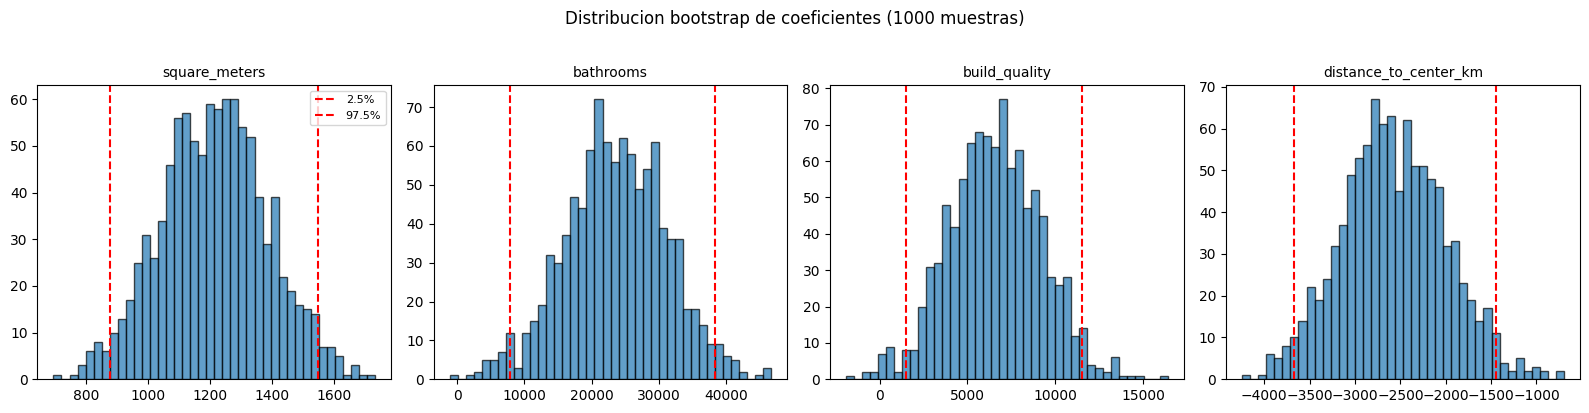

In [9]:
# Visualizar la distribucion bootstrap de cada coeficiente
fig, axes = plt.subplots(1, len(predictors), figsize=(16, 4))

for i, (ax, name) in enumerate(zip(axes, predictors)):
    ax.hist(boot_coefs[:, i], bins=40, alpha=0.7, edgecolor="black")
    ax.axvline(
        np.percentile(boot_coefs[:, i], 2.5), color="red", linestyle="--", label="2.5%"
    )
    ax.axvline(
        np.percentile(boot_coefs[:, i], 97.5),
        color="red",
        linestyle="--",
        label="97.5%",
    )
    ax.set_title(name, fontsize=10)
    if i == 0:
        ax.legend(fontsize=8)

fig.suptitle("Distribucion bootstrap de coeficientes (1000 muestras)", y=1.02)
plt.tight_layout()
plt.show()

## 3. Confidence Interval vs Prediction Interval

Aqui esta la diferencia clave:

| | Confidence Interval | Prediction Interval |
|---|---|---|
| **Que mide** | Incertidumbre sobre la **media** | Incertidumbre sobre un **valor individual** |
| **Fuentes de error** | Solo error del modelo | Error del modelo + error individual |
| **Ancho** | Estrecho | Mucho mas ancho |
| **Uso tipico** | Estadistica | Data science |

`statsmodels` calcula ambos con `get_prediction()`.

In [10]:
# Predecir para una casa especifica
nueva_casa = pd.DataFrame(
    {
        "const": [1],
        "square_meters": [80],
        "bathrooms": [2],
        "build_quality": [5],
        "distance_to_center_km": [10],
    }
)

pred = model.get_prediction(nueva_casa)
summary = pred.summary_frame(alpha=0.05)

print("Prediccion para casa de 80m², 2 banos, calidad 5, 10km del centro:")
print(f"\n  Precio predicho:       ${summary['mean'].iloc[0]:,.0f}")
print(
    f"\n  Confidence Interval (95%): ${summary['mean_ci_lower'].iloc[0]:,.0f} - ${summary['mean_ci_upper'].iloc[0]:,.0f}"
)
print(f"  (incertidumbre sobre el precio PROMEDIO de casas asi)")
print(
    f"\n  Prediction Interval (95%): ${summary['obs_ci_lower'].iloc[0]:,.0f} - ${summary['obs_ci_upper'].iloc[0]:,.0f}"
)
print(f"  (incertidumbre sobre el precio de ESTA casa en particular)")
print(
    f"\n  Ancho CI: ${summary['mean_ci_upper'].iloc[0] - summary['mean_ci_lower'].iloc[0]:,.0f}"
)
print(
    f"  Ancho PI: ${summary['obs_ci_upper'].iloc[0] - summary['obs_ci_lower'].iloc[0]:,.0f}"
)
print(f"  => El Prediction Interval es MUCHO mas ancho")

Prediccion para casa de 80m², 2 banos, calidad 5, 10km del centro:

  Precio predicho:       $185,781

  Confidence Interval (95%): $173,202 - $198,360
  (incertidumbre sobre el precio PROMEDIO de casas asi)

  Prediction Interval (95%): $108,020 - $263,543
  (incertidumbre sobre el precio de ESTA casa en particular)

  Ancho CI: $25,158
  Ancho PI: $155,523
  => El Prediction Interval es MUCHO mas ancho


## 4. Visualizando CI vs PI para todo el rango

Veamos como se ven ambos intervalos a lo largo de los metros cuadrados.

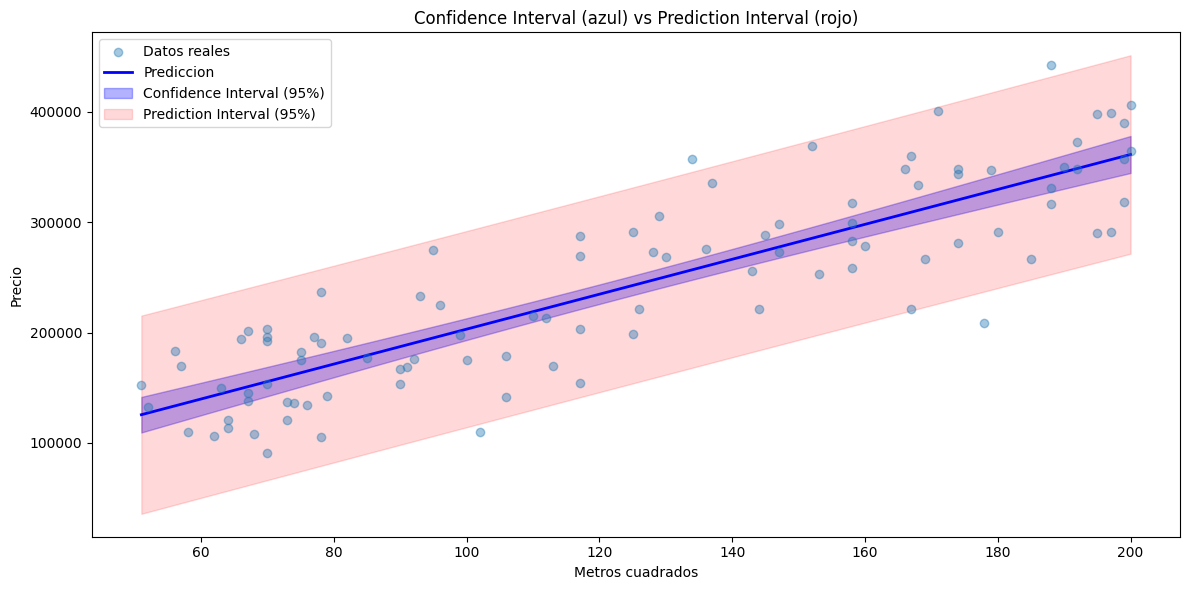

Azul estrecho = CI: donde esperamos que este el precio PROMEDIO
Rojo ancho = PI: donde esperamos que este el precio de UNA casa


In [11]:
# Modelo simple para visualizar mejor
X_simple = sm.add_constant(df["square_meters"])
model_simple = sm.OLS(df["price"], X_simple).fit()

# Generar predicciones con intervalos para un rango de m²
sqm_range = np.linspace(df["square_meters"].min(), df["square_meters"].max(), 100)
X_pred = sm.add_constant(sqm_range)
predictions = model_simple.get_prediction(X_pred)
pred_summary = predictions.summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 6))

# Datos reales
ax.scatter(df["square_meters"], df["price"], alpha=0.4, label="Datos reales", zorder=3)

# Linea de regresion
ax.plot(sqm_range, pred_summary["mean"], "b-", linewidth=2, label="Prediccion")

# Confidence interval
ax.fill_between(
    sqm_range,
    pred_summary["mean_ci_lower"],
    pred_summary["mean_ci_upper"],
    alpha=0.3,
    color="blue",
    label="Confidence Interval (95%)",
)

# Prediction interval
ax.fill_between(
    sqm_range,
    pred_summary["obs_ci_lower"],
    pred_summary["obs_ci_upper"],
    alpha=0.15,
    color="red",
    label="Prediction Interval (95%)",
)

ax.set_xlabel("Metros cuadrados")
ax.set_ylabel("Precio")
ax.set_title("Confidence Interval (azul) vs Prediction Interval (rojo)")
ax.legend()
plt.tight_layout()
plt.show()

print("Azul estrecho = CI: donde esperamos que este el precio PROMEDIO")
print("Rojo ancho = PI: donde esperamos que este el precio de UNA casa")

## 5. Bootstrap: Prediction Interval

Para capturar la incertidumbre de una prediccion individual con bootstrap, debemos sumar **dos fuentes de error**:

1. Error del modelo (diferentes coeficientes en cada muestra bootstrap)
2. Error individual (un residuo aleatorio del modelo original)

Algoritmo:
1. Bootstrap sample -> ajustar regresion -> predecir
2. Tomar un residuo aleatorio del modelo original y sumarlo
3. Repetir 1000 veces
4. Percentiles 2.5% y 97.5%

In [12]:
# Modelo original y sus residuos
lr_original = LinearRegression().fit(X_np, y_np)
residuals = y_np - lr_original.predict(X_np)

# Casa a predecir
nueva = np.array([[80, 2, 5, 10]])  # square_meters, bathrooms, build_quality, distance

rng = np.random.default_rng(42)
n_bootstrap = 1000
boot_ci_preds = np.zeros(n_bootstrap)  # solo error del modelo
boot_pi_preds = np.zeros(n_bootstrap)  # error del modelo + error individual

for i in range(n_bootstrap):
    idx = rng.choice(n, size=n, replace=True)
    lr = LinearRegression().fit(X_np[idx], y_np[idx])
    pred = lr.predict(nueva)[0]

    boot_ci_preds[i] = pred  # confidence: solo variabilidad del modelo
    boot_pi_preds[i] = pred + rng.choice(residuals)  # prediction: + residuo aleatorio

print(f"Prediccion puntual: ${lr_original.predict(nueva)[0]:,.0f}")
print(f"\nBootstrap Confidence Interval (95%):")
print(
    f"  ${np.percentile(boot_ci_preds, 2.5):,.0f} - ${np.percentile(boot_ci_preds, 97.5):,.0f}"
)
print(
    f"  Ancho: ${np.percentile(boot_ci_preds, 97.5) - np.percentile(boot_ci_preds, 2.5):,.0f}"
)
print(f"\nBootstrap Prediction Interval (95%):")
print(
    f"  ${np.percentile(boot_pi_preds, 2.5):,.0f} - ${np.percentile(boot_pi_preds, 97.5):,.0f}"
)
print(
    f"  Ancho: ${np.percentile(boot_pi_preds, 97.5) - np.percentile(boot_pi_preds, 2.5):,.0f}"
)
print(f"\n=> El PI es mucho mas ancho porque incluye la variabilidad individual")

Prediccion puntual: $185,781

Bootstrap Confidence Interval (95%):
  $173,944 - $196,790
  Ancho: $22,846

Bootstrap Prediction Interval (95%):
  $105,264 - $263,026
  Ancho: $157,762

=> El PI es mucho mas ancho porque incluye la variabilidad individual


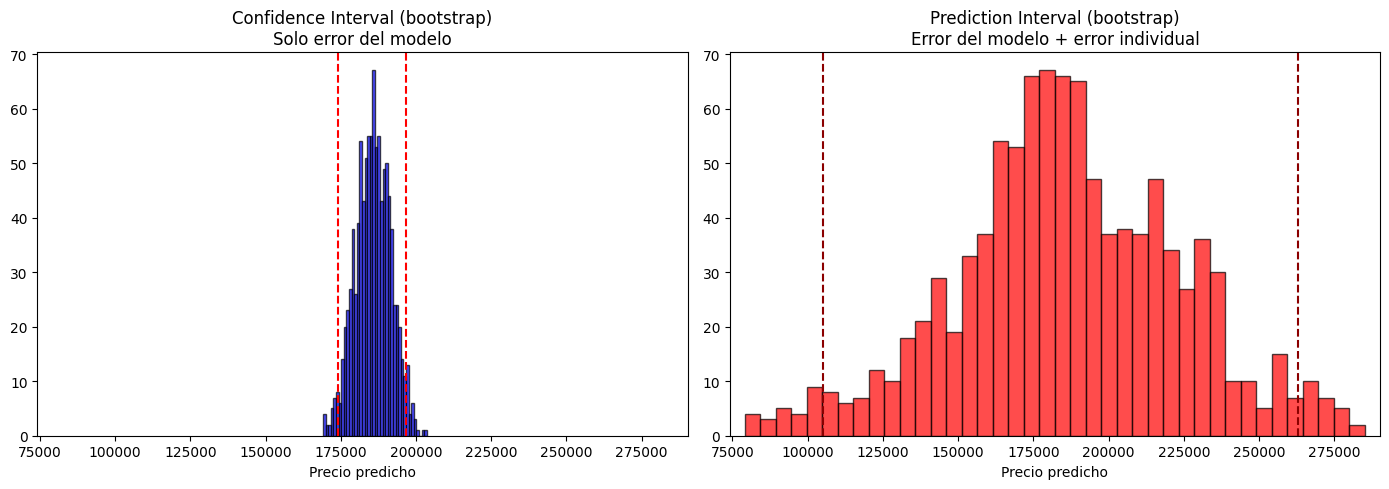

In [13]:
# Comparar visualmente CI vs PI (bootstrap)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(boot_ci_preds, bins=40, alpha=0.7, color="blue", edgecolor="black")
axes[0].axvline(np.percentile(boot_ci_preds, 2.5), color="red", linestyle="--")
axes[0].axvline(np.percentile(boot_ci_preds, 97.5), color="red", linestyle="--")
axes[0].set_title("Confidence Interval (bootstrap)\nSolo error del modelo")
axes[0].set_xlabel("Precio predicho")

axes[1].hist(boot_pi_preds, bins=40, alpha=0.7, color="red", edgecolor="black")
axes[1].axvline(np.percentile(boot_pi_preds, 2.5), color="darkred", linestyle="--")
axes[1].axvline(np.percentile(boot_pi_preds, 97.5), color="darkred", linestyle="--")
axes[1].set_title(
    "Prediction Interval (bootstrap)\nError del modelo + error individual"
)
axes[1].set_xlabel("Precio predicho")

# Mismo rango en X para comparar
xlim = (
    min(boot_pi_preds.min(), boot_ci_preds.min()) - 5000,
    max(boot_pi_preds.max(), boot_ci_preds.max()) + 5000,
)
axes[0].set_xlim(xlim)
axes[1].set_xlim(xlim)

plt.tight_layout()
plt.show()

## 6. Resumen

| Concepto | Descripcion |
|----------|-------------|
| **Confidence Interval** | Incertidumbre sobre el valor **promedio**. Estrecho |
| **Prediction Interval** | Incertidumbre sobre un valor **individual**. Ancho |
| **Bootstrap CI** | Variabilidad de coeficientes al re-muestrear los datos |
| **Bootstrap PI** | CI + un residuo aleatorio del modelo original |
| **Cual usar?** | Data scientists casi siempre necesitan el **Prediction Interval** |
| **Error comun** | Usar CI cuando deberia ser PI subestima la incertidumbre |